## Notebook to query PDB for PDB-ligand using interactions_filtered.csv

Create Uniprot-PDB-ligand data table query by PDB and ligand code.

Input:
- `interactions_filtered.csv` created from Binding Moad database by Evgenia

In [ ]:
import os
import subprocess
import pandas as pd
import numpy as np
from pathlib import Path

repo_root = !git rev-parse --show-toplevel
repo_root = repo_root[0]
os.chdir(repo_root)

data_dir = Path("data") / "interactions_filtered_Evgenia"
interactions_csv = data_dir / "input" / "interactions_filtered.csv"

df_interactions = pd.read_csv(interactions_csv)
print(f"Loaded {len(df_interactions)} rows from {interactions_csv}")
df_interactions.head()

Loaded 118308 rows from interactions_filtered.csv


,pdb,chain,ligand,bonds_src,is_valid,n_contact_atoms,n_atoms,contact_percentage
0,3SPK,A,TPV_100_A,PDB,True,41,42,0.976190
1,3SPK,B,TPV_100_A,PDB,True,37,42,0.880952
2,5RGO,A,U1G_404_A,PDB,True,16,16,1.000000
3,2Z7H,A,GG3_1302_A,PDB,True,24,24,1.000000
4,2Z7H,B,GG3_341_B,PDB,True,24,24,1.000000


In [ ]:
from pathlib import Path

# Hardcoded defaults for reruns and downstream notebook cells
input_csv    = data_dir / "working" / "interactions_filtered_pairs.csv"
raw_csv      = data_dir / "working" / "interactions_filtered_ligands_raw.csv"
output_csv   = data_dir / "interactions_filtered_ligands.csv"
pdb_script   = Path("scripts/python/pdb_to_ligand.py")

In [3]:
# Extract unique (pdb_id, ligand_code) pairs from interactions_filtered.csv
# ligand column format: CODE_SEQID_CHAIN  e.g. TPV_100_A -> ligand_code = TPV
df_interactions["ligand_code"] = df_interactions["ligand"].str.split("_").str[0]

pairs = (
    df_interactions[["pdb", "ligand_code"]]
    .drop_duplicates()
    .rename(columns={"pdb": "pdb_id"})
    .reset_index(drop=True)
)

input_csv.parent.mkdir(parents=True, exist_ok=True)
pairs.to_csv(input_csv, index=False)
print(f"Wrote {len(pairs)} unique (pdb_id, ligand_code) pairs to {input_csv}")
pairs.head()

Wrote 49806 unique (pdb_id, ligand_code) pairs to data/interactions_filtered_pairs.csv


,pdb_id,ligand_code
0,3SPK,TPV
1,5RGO,U1G
2,2Z7H,GG3
3,7U8S,LW0
4,4YAK,ACO


In [13]:
# Run pdb_to_ligand.py to resolve each pair to protein_chain, ligand_chain, smiles, etc.
# Adjust --n-jobs to the number of available cores; remove the flag to let joblib decide.
cmd = [
    "python", str(pdb_script),
    "--input",  str(input_csv),
    "--output", str(raw_csv),
]
print("Running:", " ".join(cmd))
result = subprocess.run(cmd, check=True, capture_output=False, text=True)
print("Done.")

Running: python scripts/python/pdb_to_ligand.py --input data/interactions_filtered_pairs.csv --output data/interactions_filtered_ligands_raw.csv
Input CSV:  data/interactions_filtered_pairs.csv
Output CSV: data/interactions_filtered_ligands_raw.csv
PDB cache:     data/pdb_api_cache
UniProt cache: data/uniprot_api_cache
DeepTMHMM: /work/upthomae/Meng/hp_list_DeepTMHMM/out/3line
Pairs to resolve: 49806


Pairs: 100%|██████████| 49806/49806 [1:46:47<00:00,  7.77pair/s]  


Wrote 49806 rows for 49806 pairs.
Done.


In [14]:
if not raw_csv.exists():
    raise FileNotFoundError(
        f"{raw_csv} not found. Run the cell above to generate it."
    )

df_all = pd.read_csv(raw_csv)
print(f"Loaded {len(df_all)} rows from {raw_csv}")
print(f"Rows with ligand_name:  {df_all['ligand_name'].notna().sum()}")
print(f"Rows without (not found/no contacts): {df_all['ligand_name'].isna().sum()}")
df_all.head()

Loaded 49806 rows from data/interactions_filtered_ligands_raw.csv
Rows with ligand_name:  49377
Rows without (not found/no contacts): 429


,uniprot_id,gene_name,recommendedName,scientificName,pdb_id,protein_chain,ligand_chain,ligand_code,ligand_name,smiles,percent_intracellular
0,P96084,pip,Proline iminopeptidase,Thermoplasma acidophilum (strain ATCC 25905 / ...,1MU0,A,A,PHK,"(2R,3S)-3-AMINO-1-CHLORO-4-PHENYL-BUTAN-2-OL",c1ccc(cc1)C[C@@H]([C@H](CCl)O)N,NaN
1,Q8KN66,wbpP,UDP-N-acetyl-alpha-D-glucosaminouronate 4-epim...,Pseudomonas aeruginosa,1SB9,A,A,NAD,NICOTINAMIDE-ADENINE-DINUCLEOTIDE,c1cc(c[n+](c1)[C@H]2[C@@H]([C@@H]([C@H](O2)CO[...,NaN
2,P00489,PYGM,"Glycogen phosphorylase, muscle form",Oryctolagus cuniculus,4EKY,A,A,D1J,1-(beta-D-glucopyranosyl)-5-(pent-1-yn-1-yl)py...,CCCC#CC1=CN(C(=O)NC1=O)[C@H]2[C@@H]([C@H]([C@@...,NaN
3,P03366,gag-pol,Gag-Pol polyprotein,Human immunodeficiency virus type 1 group M su...,5TER,A,A,7AY,"5-chloro-7-(2-(2-(2,4-dioxo-3,4-dihydropyrimid...",Cc1c2cc(ccc2c(cc1Oc3ccccc3OCCN4C=CC(=O)NC4=O)C...,NaN
4,Q2KDX6,NaN,Probable sugar kinase protein,Rhizobium etli (strain ATCC 51251 / DSM 11541 ...,4KAD,B,B,ADN,ADENOSINE,c1nc(c2c(n1)n(cn2)[C@H]3[C@@H]([C@@H]([C@H](O3...,NaN


In [15]:
# Function to convert smiles to molecular formula and molecular weight using RDKit
from rdkit import Chem

def smiles_to_formula(smiles):
    """Convert SMILES to molecular formula using RDKit's rdMolDescriptors."""
    from rdkit.Chem import rdMolDescriptors
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return rdMolDescriptors.CalcMolFormula(mol)

def smiles_to_mw(smiles):
    """Convert SMILES to molecular weight using RDKit's rdMolDescriptors."""
    from rdkit.Chem import rdMolDescriptors
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return rdMolDescriptors.CalcExactMolWt(mol)

def smiles_to_qed(smiles):
    """Compute QED score using RDKit's QED module."""
    from rdkit.Chem import QED
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return QED.qed(mol)

def smiles_to_num_carbon(smiles):
    """Count the number of carbon atoms in a molecule."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() == 'C')

def smiles_to_num_N_O(smiles):
    """Count the number of N and O atoms in a molecule."""
    mol = Chem.MolFromSmiles(smiles)
    if mol is None:
        return None
    return sum(1 for atom in mol.GetAtoms() if atom.GetSymbol() in ['N', 'O'])

smiles = "O=C1NC(=O)CCC1N3C(=O)c2cccc(c2C3=O)N"  # pomalidomide
print("Formula:",    smiles_to_formula(smiles))
print("Exact MW:",   smiles_to_mw(smiles))
print("QED:",        smiles_to_qed(smiles))
print("Num Carbon:", smiles_to_num_carbon(smiles))
print("Num N and O:",smiles_to_num_N_O(smiles))

Formula: C13H11N3O4
Exact MW: 273.07495583200006
QED: 0.5375391722332333
Num Carbon: 13
Num N and O: 7


In [16]:
# Add RDKit-derived molecular properties
def valid_smiles(s):
    return isinstance(s, str) and s.strip() != ""

df_all["formula"]    = df_all["smiles"].apply(lambda s: smiles_to_formula(s)    if valid_smiles(s) else None)
df_all["mw"]         = df_all["smiles"].apply(lambda s: smiles_to_mw(s)         if valid_smiles(s) else None)
df_all["qed"]        = df_all["smiles"].apply(lambda s: smiles_to_qed(s)        if valid_smiles(s) else None)
df_all["num_carbon"] = df_all["smiles"].apply(lambda s: smiles_to_num_carbon(s) if valid_smiles(s) else None)
df_all["num_N_O"]    = df_all["smiles"].apply(lambda s: smiles_to_num_N_O(s)    if valid_smiles(s) else None)

# Count unique uniprot_ids per ligand_code (same metric as all_ligands.csv)
uniprot_count = (
    df_all[df_all["uniprot_id"].notna()]
    .groupby("ligand_code")["uniprot_id"].nunique()
    .reset_index(name="uniprot_id_count")
)
df_all["uniprot_id_count"] = df_all["ligand_code"].map(
    uniprot_count.set_index("ligand_code")["uniprot_id_count"]
)

# Enforce same column order as all_ligands.csv
FINAL_COLUMNS = [
    "uniprot_id", "gene_name", "recommendedName", "scientificName", "pdb_id",
    "protein_chain", "ligand_chain", "ligand_code", "ligand_name",
    "smiles", "percent_intracellular",
    "formula", "mw", "qed", "num_carbon", "num_N_O", "uniprot_id_count",
]
df_all = df_all[FINAL_COLUMNS]
df_all

,uniprot_id,gene_name,recommendedName,scientificName,pdb_id,protein_chain,ligand_chain,ligand_code,ligand_name,smiles,percent_intracellular,formula,mw,qed,num_carbon,num_N_O,uniprot_id_count
0,P96084,pip,Proline iminopeptidase,Thermoplasma acidophilum (strain ATCC 25905 / ...,1MU0,A,A,PHK,"(2R,3S)-3-AMINO-1-CHLORO-4-PHENYL-BUTAN-2-OL",c1ccc(cc1)C[C@@H]([C@H](CCl)O)N,NaN,C10H14ClNO,199.076392,0.715318,10.0,2.0,1.0
1,Q8KN66,wbpP,UDP-N-acetyl-alpha-D-glucosaminouronate 4-epim...,Pseudomonas aeruginosa,1SB9,A,A,NAD,NICOTINAMIDE-ADENINE-DINUCLEOTIDE,c1cc(c[n+](c1)[C@H]2[C@@H]([C@@H]([C@H](O2)CO[...,NaN,C21H27N7O14P2,663.109122,0.076777,21.0,21.0,635.0
2,P00489,PYGM,"Glycogen phosphorylase, muscle form",Oryctolagus cuniculus,4EKY,A,A,D1J,1-(beta-D-glucopyranosyl)-5-(pent-1-yn-1-yl)py...,CCCC#CC1=CN(C(=O)NC1=O)[C@H]2[C@@H]([C@H]([C@@...,NaN,C15H20N2O7,340.127051,0.387721,15.0,9.0,1.0
3,P03366,gag-pol,Gag-Pol polyprotein,Human immunodeficiency virus type 1 group M su...,5TER,A,A,7AY,"5-chloro-7-(2-(2-(2,4-dioxo-3,4-dihydropyrimid...",Cc1c2cc(ccc2c(cc1Oc3ccccc3OCCN4C=CC(=O)NC4=O)C...,NaN,C24H18ClN3O4,447.098584,0.472305,24.0,7.0,1.0
4,Q2KDX6,NaN,Probable sugar kinase protein,Rhizobium etli (strain ATCC 51251 / DSM 11541 ...,4KAD,B,B,ADN,ADENOSINE,c1nc(c2c(n1)n(cn2)[C@H]3[C@@H]([C@@H]([C@H](O3...,NaN,C10H13N5O4,267.096754,0.490520,10.0,9.0,77.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49801,P49238,CX3CR1,CX3C chemokine receptor 1,Homo sapiens,7XBW,R,R,CLR,CHOLESTEROL,CC(C)CCC[C@@H](C)[C@H]1CC[C@@H]2[C@@]1(CC[C@H]...,0.293447,C27H46O,386.354866,0.488312,27.0,1.0,62.0
49802,P17413,frdC,Fumarate reductase cytochrome b subunit,Wolinella succinogenes (strain ATCC 29543 / DS...,2BS4,C,E,DMW,"2,3-DIMETHYL-1,4-NAPHTHOQUINONE",CC1=C(C(=O)c2ccccc2C1=O)C,NaN,C12H10O2,186.068080,0.623069,12.0,2.0,1.0
49803,P20136,GSTM2,Glutathione S-transferase 2,Gallus gallus,1C72,A,A,EPY,1-HYDROXY-2-S-GLUTATHIONYL-3-PARA-NITROPHENOXY...,c1cc(ccc1[N+](=O)[O-])OC[C@H](CO)SC[C@@H](C(=O...,NaN,C19H26N4O10S,502.136964,0.117320,19.0,14.0,1.0
49804,A5HEI4,atpH,ATP synthase subunit c,Limnospira platensis HN01,2WIE,D,D,CVM,CYMAL-4,C1CCC(CC1)CCCCO[C@H]2[C@@H]([C@H]([C@@H]([C@H]...,NaN,C22H40O11,480.257062,0.178679,22.0,11.0,3.0


In [17]:
# Save enriched table
df_all.to_csv(output_csv, index=False)
print(f"Saved {len(df_all)} rows to {output_csv}")

Saved 49806 rows to interactions_filtered_ligands.csv


___
### EDA

Total pairs:       49806
Resolved (found):  49377
Not resolved:      429
Unique ligand_code: 22338


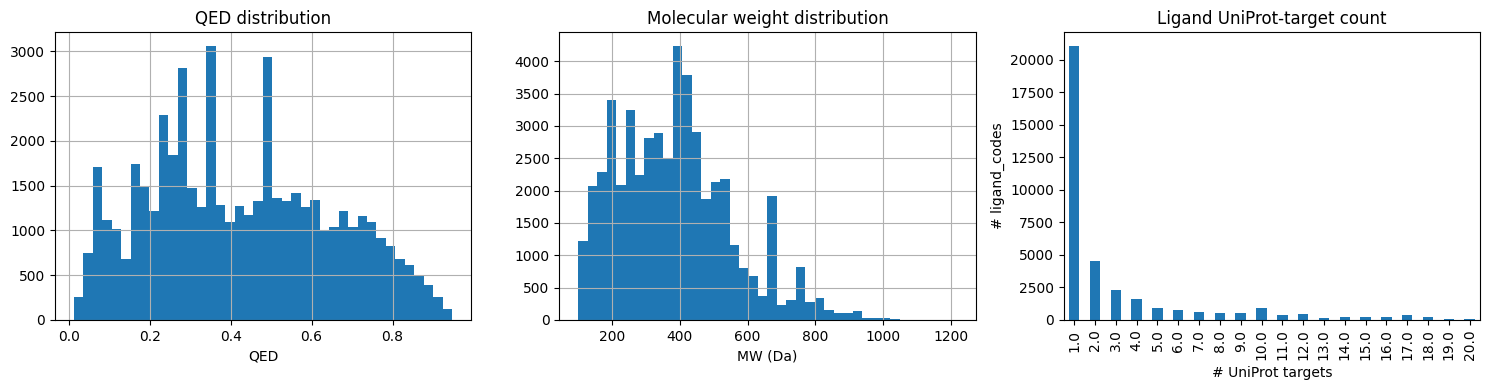

In [8]:
import matplotlib.pyplot as plt

df_found    = df_all[df_all["ligand_name"].notna()]
df_notfound = df_all[df_all["ligand_name"].isna()]

print(f"Total pairs:       {len(df_all)}")
print(f"Resolved (found):  {len(df_found)}")
print(f"Not resolved:      {len(df_notfound)}")
print(f"Unique ligand_code: {df_found['ligand_code'].nunique()}")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df_found["qed"].dropna().hist(bins=40, ax=axes[0])
axes[0].set_title("QED distribution")
axes[0].set_xlabel("QED")

df_found["mw"].dropna().hist(bins=40, ax=axes[1])
axes[1].set_title("Molecular weight distribution")
axes[1].set_xlabel("MW (Da)")

df_found["uniprot_id_count"].dropna().value_counts().sort_index().head(20).plot(
    kind="bar", ax=axes[2]
)
axes[2].set_title("Ligand UniProt-target count")
axes[2].set_xlabel("# UniProt targets")
axes[2].set_ylabel("# ligand_codes")

plt.tight_layout()
plt.show()

___
### Filter to human proteins

In [22]:
all_species = df_all["scientificName"].dropna().astype(str).unique()
all_species = sorted(all_species)
all_species


['Abies grandis',
 'Abrus precatorius',
 'Acanthamoeba castellanii',
 'Acanthamoeba castellanii (strain ATCC 30010 / Neff)',
 'Acanthamoeba polyphaga mimivirus',
 'Acanthopagrus schlegelii',
 'Acaryochloris marina (strain MBIC 11017)',
 'Acetivibrio thermocellus',
 'Acetivibrio thermocellus (strain ATCC 27405 / DSM 1237 / JCM 9322 / NBRC 103400 / NCIMB 10682 / NRRL B-4536 / VPI 7372)',
 'Acetoanaerobium sticklandii (strain ATCC 12662 / DSM 519 / JCM 1433 / CCUG 9281 / NCIMB 10654 / HF)',
 'Acetobacter aceti',
 'Acetobacter pasteurianus',
 'Acetomicrobium mobile (strain ATCC BAA-54 / DSM 13181 / JCM 12221 / NGA)',
 'Acholeplasma laidlawii (strain PG-8A)',
 'Achromobacter cycloclastes',
 'Achromobacter obae',
 'Acidithiobacillus ferrooxidans',
 'Acidithiobacillus ferrooxidans (strain ATCC 23270 / DSM 14882 / CIP 104768 / NCIMB 8455)',
 'Acidithiobacillus thiooxidans',
 'Acidobacterium capsulatum (strain ATCC 51196 / DSM 11244 / BCRC 80197 / JCM 7670 / NBRC 15755 / NCIMB 13165 / 161)',
 '

In [29]:
df_human = df_all[df_all["scientificName"] == "Homo sapiens"]
print(df_human.shape)
df_human.head()



(16118, 17)


,uniprot_id,gene_name,recommendedName,scientificName,pdb_id,protein_chain,ligand_chain,ligand_code,ligand_name,smiles,percent_intracellular,formula,mw,qed,num_carbon,num_N_O,uniprot_id_count
57,Q12852,MAP3K12,Mitogen-activated protein kinase kinase kinase 12,Homo sapiens,5CEO,A,A,50D,"2-[[6-[3,3-bis(fluoranyl)pyrrolidin-1-yl]-4-[1...",c1cnc(cc1C#N)Nc2cc(cc(n2)N3CCC(C3)(F)F)C4CCN(C...,1.0,C23H26F2N6O,440.213616,0.762353,23.0,7.0,1.0
59,P34913,EPHX2,Bifunctional epoxide hydrolase 2,Homo sapiens,4OD0,A,A,2RV,1-(1-propanoylpiperidin-4-yl)-3-[4-(trifluorom...,CCC(=O)N1CCC(CC1)NC(=O)Nc2ccc(cc2)OC(F)(F)F,1.0,C16H20F3N3O3,359.145676,0.867824,16.0,6.0,1.0
63,P27487,DPP4,Dipeptidyl peptidase 4,Homo sapiens,3H0C,A,A,PS4,N-({(2S)-1-[(3R)-3-amino-4-(3-chlorophenyl)but...,CS(=O)(=O)c1cccc(c1)C(=O)NC[C@@H]2CCCN2C(=O)C[...,0.0,C23H28ClN3O4S,477.148905,0.606388,23.0,7.0,1.0
64,P63096,GNAI1,Guanine nucleotide-binding protein G(i) subuni...,Homo sapiens,3UMS,A,A,GDP,GUANOSINE-5'-DIPHOSPHATE,c1nc2c(n1[C@H]3[C@@H]([C@@H]([C@H](O3)CO[P@](=...,1.0,C10H15N5O11P2,443.024330,0.228822,10.0,16.0,329.0
68,P55055,NR1H2,Oxysterols receptor LXR-beta,Homo sapiens,4RAK,B,B,652,2-{2-[2-(2-chlorophenyl)propan-2-yl]-1-[3'-(me...,CC(C)(c1ccccc1Cl)c2nc(cn2c3ccc(cc3)c4cccc(c4)S...,1.0,C28H29ClN2O3S,508.158741,0.338814,28.0,5.0,1.0


In [27]:
df_all[df_all["uniprot_id"] == "Q96SW2"]


,uniprot_id,gene_name,recommendedName,scientificName,pdb_id,protein_chain,ligand_chain,ligand_code,ligand_name,smiles,percent_intracellular,formula,mw,qed,num_carbon,num_N_O,uniprot_id_count
4349,Q96SW2,CRBN,Protein cereblon,Homo sapiens,7BQV,A,A,F4U,"2-[(3~{S})-2,6-bis(oxidanylidene)piperidin-3-y...",c1cc2c(cc1O)C(=O)N(C2=O)[C@H]3CCC(=O)NC3=O,1.0,C13H10N2O5,274.058971,0.689710,13.0,7.0,1.0
19899,Q96SW2,CRBN,Protein cereblon,Homo sapiens,5FQD,E,E,LVY,S-Lenalidomide,c1cc2c(c(c1)N)CN(C2=O)[C@H]3CCC(=O)NC3=O,1.0,C13H13N3O3,259.095691,0.549435,13.0,6.0,3.0
23891,Q96SW2,CRBN,Protein cereblon,Homo sapiens,7BQU,A,A,EF2,S-Thalidomide,c1ccc2c(c1)C(=O)N(C2=O)[C@H]3CCC(=O)NC3=O,1.0,C13H10N2O4,258.064057,0.723359,13.0,6.0,4.0


In [28]:
df_all[df_all["pdb_id"] == "8D7V"]


,uniprot_id,gene_name,recommendedName,scientificName,pdb_id,protein_chain,ligand_chain,ligand_code,ligand_name,smiles,percent_intracellular,formula,mw,qed,num_carbon,num_N_O,uniprot_id_count
